In [ ]:
# === Kaggle API token ===
# Generate a new token at: kaggle.com -> Settings -> API -> 'Generate New Token'
# (use the 'API Tokens (Recommended)' section -- the new-style token starts with 'KGAT_').
# If you need to download on a new machine, uncomment the line below and paste your token locally.
import os, sys, subprocess, re
# os.environ['KAGGLE_API_TOKEN'] = 'KGAT_token'

print('kernel python  :', sys.executable)
print('kernel version :', sys.version.split()[0])
if sys.version_info < (3, 10):
    raise RuntimeError('kagglehub>=0.4.1 requires Python >= 3.10 for KGAT_ tokens')

def _version_tuple(version_text):
    nums = [int(x) for x in re.findall(r'\d+', version_text)[:3]]
    return tuple((nums + [0, 0, 0])[:3])

try:
    import kagglehub
    if _version_tuple(kagglehub.__version__) < (0, 4, 1):
        raise ImportError(f'kagglehub {kagglehub.__version__} is too old')
except ImportError:
    print('Installing kagglehub>=0.4.1 into this notebook kernel...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub>=0.4.1'])
    import kagglehub
print('kagglehub      :', kagglehub.__version__)


kernel python  : /Users/youssefahmedsaad/Downloads/task-meriti/.venv/bin/python
kernel version : 3.12.13
kagglehub      : 1.0.0


## 1. Setup

Standard imports and a fixed seed. `DEVICE` picks GPU when available.

In [19]:
import os, random, math, json, time, shutil
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Optional, Dict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# Notebook-safe setting: macOS/Jupyter multiprocessing workers often exit
# without surfacing the real dataset exception. Keep loading in-process.
DATALOADER_NUM_WORKERS = 0
print('device =', DEVICE)
print('dataloader workers =', DATALOADER_NUM_WORKERS)

device = cpu
dataloader workers = 0


## 2. Dataset constants

We use the **DeepGlobe Land Cover Classification** dataset (the 2018 challenge release on Kaggle: `balraj98/deepglobe-land-cover-classification-dataset`). Six land-cover classes, high-resolution satellite imagery (2448x2448, 50 cm/pixel), masks stored as RGB color-coded PNGs.

| ID | Class       | RGB color in mask |
|----|-------------|-------------------|
| 0  | Urban       | (0, 255, 255) cyan    |
| 1  | Agriculture | (255, 255, 0) yellow  |
| 2  | Rangeland   | (255, 0, 255) magenta |
| 3  | Forest      | (0, 255, 0) green     |
| 4  | Water       | (0, 0, 255) blue      |
| 5  | Barren      | (255, 255, 255) white |

`IGNORE_INDEX = 255` is reserved for 'no label here' -- every pixel that isn't a sampled point uses this value, and the loss skips it. Black pixels `(0,0,0)` in the raw RGB mask mark 'unknown' and also become `IGNORE_INDEX`.


In [20]:
NUM_CLASSES = 6
IGNORE_INDEX = 255
CLASS_NAMES = ['urban', 'agriculture', 'rangeland', 'forest', 'water', 'barren']

# DeepGlobe official RGB color codes for each class
COLOR_TO_CLASS = {
    (  0, 255, 255): 0,   # urban land   - cyan
    (255, 255,   0): 1,   # agriculture  - yellow
    (255,   0, 255): 2,   # rangeland    - magenta
    (  0, 255,   0): 3,   # forest       - green
    (  0,   0, 255): 4,   # water        - blue
    (255, 255, 255): 5,   # barren land  - white
    (  0,   0,   0): IGNORE_INDEX,  # unknown
}

# Visualization palette - same colors as the dataset uses
PALETTE = np.array([
    [  0, 255, 255],   # urban
    [255, 255,   0],   # agriculture
    [255,   0, 255],   # rangeland
    [  0, 255,   0],   # forest
    [  0,   0, 255],   # water
    [255, 255, 255],   # barren
], dtype=np.uint8)

## 3. Partial Cross-Entropy loss

This is the central piece of the assignment. Two things to implement:

**(a) Focal loss at every pixel.** Standard CE gives every pixel equal weight, so confident easy pixels swamp the gradient. Focal loss down-weights well-classified pixels by a factor $(1-p_t)^\gamma$:

$$\mathrm{FL}(p_t) = -\alpha\,(1-p_t)^\gamma\,\log p_t$$

**(b) Mask the loss to labeled points only.** With sparse point labels, *most* pixels carry `IGNORE_INDEX`. Build a binary mask `MASK_labeled` that is 1 where a label exists and 0 elsewhere, then average over the number of labeled pixels — exactly the formula in the brief.

A subtlety: PyTorch's `F.cross_entropy(..., ignore_index=...)` already filters ignored pixels, but it does so for *plain* CE, not for focal CE, and it doesn't expose `MASK_labeled` for inspection. We do the masking ourselves so the implementation matches the formula one-to-one.

In [21]:
class PartialFocalCELoss(nn.Module):
    """Partial focal cross-entropy for sparse point labels.

    Implements   pfCE = sum( FocalLoss(pred, GT) * MASK_labeled ) / sum(MASK_labeled)

    Args:
        ignore_index: pixel value that means "unlabeled" — these are excluded
        gamma:        focal-loss focusing parameter (gamma=0 reduces to plain CE)
        alpha:        per-class weight tensor of shape [C], or None for uniform
    """
    def __init__(self, ignore_index: int = 255, gamma: float = 2.0,
                 alpha: Optional[torch.Tensor] = None):
        super().__init__()
        self.ignore_index = ignore_index
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer('alpha', alpha.float())
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits  : [B, C, H, W]
        # targets : [B, H, W]   class id at labeled pixels, ignore_index elsewhere
        if logits.shape[-2:] != targets.shape[-2:]:
            logits = F.interpolate(logits, size=targets.shape[-2:],
                                   mode='bilinear', align_corners=False)
        B, C, H, W = logits.shape

        # Build MASK_labeled (1 at labeled points, 0 elsewhere)
        mask_labeled = (targets != self.ignore_index).float()      # [B,H,W]
        n_labeled = mask_labeled.sum()
        if n_labeled.item() == 0:
            # No supervision in this batch — return zero with grad
            return logits.sum() * 0.0

        # Replace ignore_index with 0 so gather() is safe; mask kills it later
        safe_targets = targets.clone()
        safe_targets[targets == self.ignore_index] = 0
        safe_targets = safe_targets.long()

        # Per-pixel cross-entropy term: -log p_t
        log_probs = F.log_softmax(logits, dim=1)                   # [B,C,H,W]
        log_pt = log_probs.gather(1, safe_targets.unsqueeze(1)).squeeze(1)  # [B,H,W]
        pt = log_pt.exp()

        # Focal modulation
        focal_term = (1.0 - pt) ** self.gamma * (-log_pt)          # [B,H,W]

        # Per-class alpha weighting
        if self.alpha is not None:
            alpha_map = self.alpha[safe_targets]                   # [B,H,W]
            focal_term = focal_term * alpha_map

        # Mask to labeled points and average over the number of points
        loss = (focal_term * mask_labeled).sum() / n_labeled
        return loss


# Quick gradient + correctness sanity check
def _self_test():
    torch.manual_seed(0)
    logits = torch.randn(2, NUM_CLASSES, 16, 16, requires_grad=True)
    targets = torch.full((2, 16, 16), IGNORE_INDEX, dtype=torch.long)
    # Drop a handful of labels in
    for b in range(2):
        for c in range(NUM_CLASSES):
            for _ in range(3):
                y = torch.randint(0, 16, (1,)).item()
                x = torch.randint(0, 16, (1,)).item()
                targets[b, y, x] = c

    # gamma=0 should match plain CE with ignore_index
    loss_pfce_g0 = PartialFocalCELoss(IGNORE_INDEX, gamma=0.0)(logits, targets)
    loss_ce      = F.cross_entropy(logits, targets, ignore_index=IGNORE_INDEX)
    print(f'pfCE(gamma=0)  = {loss_pfce_g0.item():.6f}')
    print(f'F.cross_entropy = {loss_ce.item():.6f}')
    assert torch.allclose(loss_pfce_g0, loss_ce, atol=1e-5), 'pfCE(gamma=0) != CE'

    # gamma=2 should give a finite, smaller loss (well-classified pixels down-weighted)
    loss_pfce_g2 = PartialFocalCELoss(IGNORE_INDEX, gamma=2.0)(logits, targets)
    print(f'pfCE(gamma=2)  = {loss_pfce_g2.item():.6f}')
    loss_pfce_g2.backward()
    assert logits.grad is not None and torch.isfinite(logits.grad).all()
    print('gradient flows ok')

_self_test()

pfCE(gamma=0)  = 2.152864
F.cross_entropy = 2.152864
pfCE(gamma=2)  = 1.706081
gradient flows ok


## 4. Simulating point labels from a dense mask

Real point-annotation data is rare. We *simulate* it: take the full mask, drop all but a handful of pixels per class, replace the rest with `IGNORE_INDEX`. Two sampling modes:

- **balanced** — `points_per_class` from each class. Forces the loss to see every class, even rare ones (roads, water).
- **uniform** — `total_points` drawn at random, regardless of class. Mimics a real annotator clicking around an image — common classes dominate.

Which is better? That's one of the experiments in §7.

In [22]:
def sample_point_labels(mask: torch.Tensor,
                        num_classes: int,
                        points_per_class: int = 20,
                        ignore_index: int = 255,
                        balanced: bool = True,
                        total_points: Optional[int] = None) -> torch.Tensor:
    """Return a sparse target the same shape as `mask`."""
    sparse = torch.full_like(mask, fill_value=ignore_index)
    if balanced:
        for c in range(num_classes):
            ys, xs = torch.where(mask == c)
            if len(ys) == 0:
                continue
            k = min(points_per_class, len(ys))
            choice = torch.randperm(len(ys))[:k]
            sparse[ys[choice], xs[choice]] = c
    else:
        valid = mask != ignore_index
        ys, xs = torch.where(valid)
        if len(ys) > 0:
            k = min(total_points or points_per_class * num_classes, len(ys))
            choice = torch.randperm(len(ys))[:k]
            sparse[ys[choice], xs[choice]] = mask[ys[choice], xs[choice]]
    return sparse

## 5. Loading DeepGlobe Land Cover

We use the **DeepGlobe Land Cover Classification** dataset (Kaggle: `balraj98/deepglobe-land-cover-classification-dataset`). Each sample is a 2448x2448 satellite tile with a matching RGB-coded mask; we pair `*_sat.jpg` with `*_mask.png`, convert each pixel's RGB triplet to an integer class ID via lookup, and resize on the fly.

**Setup.** This needs a Kaggle API token. Generate one at *kaggle.com -> Settings -> API -> 'Generate New Token'* (use the **API Tokens (Recommended)** section -- the new-style token starts with `KGAT_`) and paste it into the env-var cell at the top of this notebook. The first run downloads ~3 GB via `kagglehub`; subsequent runs reuse the cached files.


In [23]:
DATA_ROOT = Path('data')
IMG_DIR  = DATA_ROOT / 'images'
MASK_DIR = DATA_ROOT / 'masks'

def rgb_mask_to_class(rgb_arr: np.ndarray,
                      mapping: Dict = COLOR_TO_CLASS,
                      ignore_index: int = IGNORE_INDEX) -> np.ndarray:
    """Convert an HxWx3 RGB mask to an HxW class-id mask."""
    out = np.full(rgb_arr.shape[:2], ignore_index, dtype=np.uint8)
    for color, cls in mapping.items():
        matches = np.all(rgb_arr == np.array(color, dtype=np.uint8), axis=-1)
        out[matches] = cls
    return out


def prepare_deepglobe(n_samples: int = 300, force: bool = False):
    """Download DeepGlobe Land Cover via kagglehub (uses KAGGLE_API_TOKEN env var)."""
    if IMG_DIR.exists() and MASK_DIR.exists() and not force:
        n_img  = len(list(IMG_DIR.glob('*.png')))
        n_mask = len(list(MASK_DIR.glob('*.png')))
        if n_img >= n_samples and n_mask >= n_samples:
            print(f'Already prepared: {n_img} images, {n_mask} masks')
            return

    shutil.rmtree(IMG_DIR, ignore_errors=True)
    shutil.rmtree(MASK_DIR, ignore_errors=True)
    IMG_DIR.mkdir(parents=True, exist_ok=True)
    MASK_DIR.mkdir(parents=True, exist_ok=True)

    # Install kagglehub if not already present (>=0.4.1 supports the new token)
    try:
        import kagglehub
        if tuple(int(x) for x in kagglehub.__version__.split('.')[:2]) < (0, 4):
            raise ImportError('kagglehub too old')
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                               'kagglehub>=0.4.1'])
        import kagglehub

    # Confirm the token is present if we actually need to download.
    token = os.environ.get('KAGGLE_API_TOKEN', '').strip()
    if not token or token == 'KGAT_REPLACE_ME':
        raise RuntimeError(
            'KAGGLE_API_TOKEN env var not set. '
            'Set os.environ["KAGGLE_API_TOKEN"] = "KGAT_..." before downloading.'
        )

    print('Downloading DeepGlobe Land Cover via kagglehub...')
    raw_dir = Path(kagglehub.dataset_download(
        'balraj98/deepglobe-land-cover-classification-dataset'
    ))
    print(f'Downloaded to: {raw_dir}')

    # Locate the directory that actually contains *_sat.jpg files. Prefer one
    # named 'train' if multiple candidates exist, since DeepGlobe ships train/valid/test
    # but only train/ has the masks.
    train_dir = None
    candidates = [c for c in raw_dir.rglob('*') if c.is_dir() and any(c.glob('*_sat.jpg'))]
    for cand in candidates:
        if cand.name.lower() == 'train':
            train_dir = cand; break
    if train_dir is None and candidates:
        train_dir = candidates[0]
    if train_dir is None:
        raise FileNotFoundError(
            f'Could not find *_sat.jpg under {raw_dir}. '
            f'Top-level contents: {list(raw_dir.iterdir())[:10]}'
        )
    print(f'Found training directory: {train_dir}')

    sat_files = sorted(train_dir.glob('*_sat.jpg'))[:n_samples]
    print(f'Processing {len(sat_files)} samples...')

    kept = 0
    for i, sat_path in enumerate(sat_files):
        mask_path = sat_path.with_name(sat_path.stem.replace('_sat', '_mask') + '.png')
        if not mask_path.exists():
            continue
        Image.open(sat_path).convert('RGB').save(IMG_DIR / f'{i:04d}.png')
        mask_rgb = np.array(Image.open(mask_path).convert('RGB'))
        mask_cls = rgb_mask_to_class(mask_rgb)
        Image.fromarray(mask_cls).save(MASK_DIR / f'{i:04d}.png')
        kept += 1

    print(f'Prepared {kept} (image, mask) pairs in {DATA_ROOT}/')


prepare_deepglobe(n_samples=300)

# Aggregate sanity check across all prepared masks.
mask_paths = sorted(MASK_DIR.glob('*.png'))
if not mask_paths:
    raise FileNotFoundError(f'No masks found in {MASK_DIR}')

class_counts = {i: 0 for i in range(NUM_CLASSES)}
ignore_count = 0
total_pixels = 0
mask_shape = None
for mask_path in mask_paths:
    mask = np.array(Image.open(mask_path))
    mask_shape = mask_shape or mask.shape
    vals, counts = np.unique(mask, return_counts=True)
    for v, c in zip(vals, counts):
        v, c = int(v), int(c)
        total_pixels += c
        if 0 <= v < NUM_CLASSES:
            class_counts[v] += c
        else:
            ignore_count += c

print('\nAggregate mask sanity check:')
print(f'  masks counted: {len(mask_paths)}')
print(f'  mask shape   : {mask_shape}')
print('  class distribution across prepared masks:')
for cls in range(NUM_CLASSES):
    c = class_counts[cls]
    print(f'    class {cls:3d} ({CLASS_NAMES[cls]}): {c:>12,} pixels  ({100*c/total_pixels:5.2f}%)')
if ignore_count:
    print(f'    ignore    ({IGNORE_INDEX}): {ignore_count:>12,} pixels  ({100*ignore_count/total_pixels:5.2f}%)')

Already prepared: 300 images, 300 masks

Aggregate mask sanity check:
  masks counted: 300
  mask shape   : (2448, 2448)
  class distribution across prepared masks:
    class   0 (urban):  185,341,389 pixels  (10.31%)
    class   1 (agriculture): 1,026,798,542 pixels  (57.11%)
    class   2 (rangeland):  158,939,931 pixels  ( 8.84%)
    class   3 (forest):  191,414,516 pixels  (10.65%)
    class   4 (water):   52,833,621 pixels  ( 2.94%)
    class   5 (barren):  181,609,329 pixels  (10.10%)
    ignore    (255):      873,872 pixels  ( 0.05%)


## 6. Torch dataset

Each `__getitem__` returns

- `image`  — `[3, H, W]` float tensor in `[0,1]`
- `mask`   — `[H, W]` long tensor with full ground truth (used **only for evaluation**)
- `points` — `[H, W]` long tensor with sparse labels (used **for training**)

The dataset re-samples points every epoch via a configurable `points_per_class` / `balanced` / `total_points`. Random augmentation: horizontal/vertical flip — same flip applied to image, mask, and points.

In [42]:
class LandCoverDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=256,
                 points_per_class=20, balanced=True, total_points=None,
                 augment=True, seed=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.size = size
        self.points_per_class = points_per_class
        self.balanced = balanced
        self.total_points = total_points
        self.augment = augment
        self.images = sorted(self.image_dir.glob('*.png'))
        if not self.images:
            raise FileNotFoundError(f'No images in {self.image_dir}')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.mask_dir / img_path.name
        img = Image.open(img_path).convert('RGB').resize(
            (self.size, self.size), Image.BILINEAR)
        mask = Image.open(mask_path).resize(
            (self.size, self.size), Image.NEAREST)

        img_np  = np.array(img,  dtype=np.uint8)
        mask_np = np.array(mask, dtype=np.uint8)

        if self.augment:
            if random.random() < 0.5:
                img_np  = np.ascontiguousarray(img_np[:, ::-1])
                mask_np = np.ascontiguousarray(mask_np[:, ::-1])
            if random.random() < 0.5:
                img_np  = np.ascontiguousarray(img_np[::-1, :])
                mask_np = np.ascontiguousarray(mask_np[::-1, :])

        img_t  = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask_np).long()
        points_t = sample_point_labels(
            mask_t, NUM_CLASSES,
            points_per_class=self.points_per_class,
            ignore_index=IGNORE_INDEX,
            balanced=self.balanced,
            total_points=self.total_points,
        )
        return {'image': img_t, 'mask': mask_t, 'points': points_t,
                'id': img_path.stem}

### Sanity check: visualize the simulated points

Sparse points should be a tiny fraction of the image — confirm visually before training.

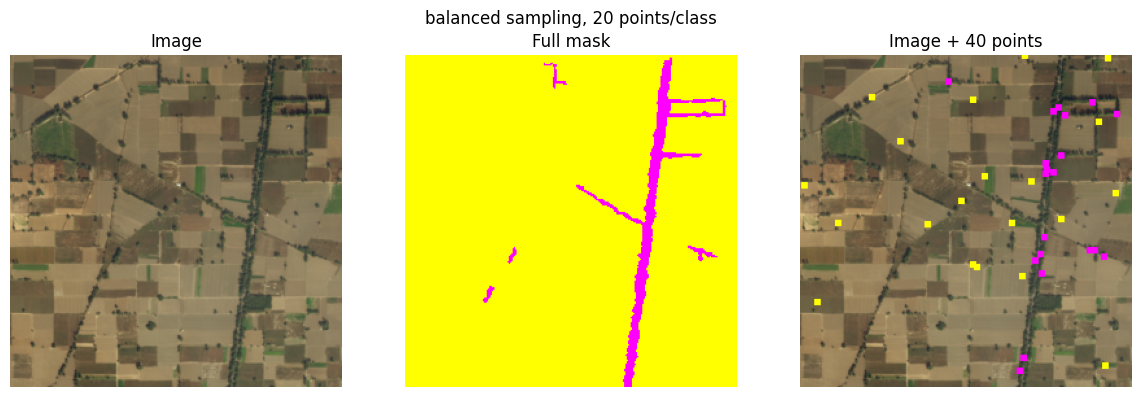

In [25]:
def colorize(mask_np: np.ndarray) -> np.ndarray:
    """Map class ids -> RGB using PALETTE; ignore_index -> black."""
    out = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    valid = mask_np != IGNORE_INDEX
    ids = np.clip(mask_np, 0, NUM_CLASSES - 1)
    out[valid] = PALETTE[ids[valid]]
    return out


def visualize_sample(ds, idx=0, title=''):
    s = ds[idx]
    img = (s['image'].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    mask = s['mask'].numpy()
    pts  = s['points'].numpy()

    # Dilate points so they're visible
    pts_vis = pts.copy()
    overlay = img.copy()
    ys, xs = np.where(pts != IGNORE_INDEX)
    for y, x in zip(ys, xs):
        c = pts[y, x]
        y0, y1 = max(0, y-2), min(pts.shape[0], y+3)
        x0, x1 = max(0, x-2), min(pts.shape[1], x+3)
        overlay[y0:y1, x0:x1] = PALETTE[c]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);              axes[0].set_title('Image');         axes[0].axis('off')
    axes[1].imshow(colorize(mask));   axes[1].set_title('Full mask');     axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title(f'Image + {len(ys)} points'); axes[2].axis('off')
    fig.suptitle(title)
    plt.tight_layout(); plt.show()


_demo_ds = LandCoverDataset(IMG_DIR, MASK_DIR, size=256,
                            points_per_class=20, balanced=True, augment=False)
visualize_sample(_demo_ds, idx=0, title='balanced sampling, 20 points/class')

## 7. A small U-Net

A compact U-Net is enough for the dataset slice we're using. The point of this exercise is the *loss*, not the architecture — a heavier backbone (ResNet, EfficientNet, SegFormer, …) would slot in trivially.

In [43]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES, base=32):
        super().__init__()
        self.d1 = DoubleConv(in_channels, base)
        self.d2 = DoubleConv(base,   base*2)
        self.d3 = DoubleConv(base*2, base*4)
        self.d4 = DoubleConv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        self.u3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.c3 = DoubleConv(base*8, base*4)
        self.u2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.c2 = DoubleConv(base*4, base*2)
        self.u1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.c1 = DoubleConv(base*2, base)
        self.head = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.pool(x1))
        x3 = self.d3(self.pool(x2))
        x4 = self.d4(self.pool(x3))
        x = self.u3(x4); x = self.c3(torch.cat([x, x3], 1))
        x = self.u2(x);  x = self.c2(torch.cat([x, x2], 1))
        x = self.u1(x);  x = self.c1(torch.cat([x, x1], 1))
        return self.head(x)

## 8. Metrics and training loops

Standard segmentation metrics: confusion matrix → per-class IoU, mIoU, pixel accuracy. Evaluation is always against the **full** mask, never against the points — the points are only used for the loss.

In [27]:
def fast_hist(pred: torch.Tensor, target: torch.Tensor,
              num_classes: int = NUM_CLASSES,
              ignore_index: int = IGNORE_INDEX) -> torch.Tensor:
    valid = (target != ignore_index) & (target >= 0) & (target < num_classes)
    pred = pred[valid].view(-1)
    target = target[valid].view(-1)
    return torch.bincount(num_classes * target + pred,
                          minlength=num_classes**2).reshape(num_classes, num_classes)


def metrics_from_hist(hist: torch.Tensor) -> Dict:
    hist = hist.float()
    iou = torch.diag(hist) / (hist.sum(1) + hist.sum(0) - torch.diag(hist)).clamp_min(1)
    acc = torch.diag(hist).sum() / hist.sum().clamp_min(1)
    return {
        'mIoU': iou.mean().item(),
        'pixel_acc': acc.item(),
        'class_IoU': {CLASS_NAMES[i]: float(iou[i]) for i in range(NUM_CLASSES)},
    }


def train_one_epoch(model, loader, criterion, optimizer, target_key='points'):
    model.train()
    total = 0.0; n = 0
    for batch in loader:
        x = batch['image'].to(DEVICE)
        y = batch[target_key].to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * x.size(0); n += x.size(0)
    return total / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    hist = torch.zeros(NUM_CLASSES, NUM_CLASSES, device=DEVICE)
    for batch in loader:
        x = batch['image'].to(DEVICE)
        y = batch['mask'].to(DEVICE)
        pred = model(x).argmax(1)
        hist += fast_hist(pred, y)
    return metrics_from_hist(hist.cpu())

## 9. Experiment runner

One function — `run_experiment` — captures everything that varies between runs (sampling, loss type, hyper-params) and returns a history of metrics. Every experiment uses the same train/val split and the same seed for fair comparison.

In [28]:
@dataclass
class ExpConfig:
    name: str
    points_per_class: int = 20
    balanced: bool = True
    total_points: Optional[int] = None     # only used when balanced=False
    target_key: str = 'points'             # 'points' for partial-sup, 'mask' for full-sup baseline
    gamma: float = 2.0                     # 0.0 -> plain CE, >0 -> focal CE
    epochs: int = 12
    batch_size: int = 8
    lr: float = 1e-3
    size: int = 256


def make_loaders(cfg: ExpConfig, n_samples_cap: Optional[int] = None):
    full = LandCoverDataset(IMG_DIR, MASK_DIR,
                            size=cfg.size,
                            points_per_class=cfg.points_per_class,
                            balanced=cfg.balanced,
                            total_points=cfg.total_points,
                            augment=True)
    if n_samples_cap is not None:
        full = Subset(full, list(range(min(n_samples_cap, len(full)))))
    n_val = max(1, int(0.2 * len(full)))
    n_train = len(full) - n_val
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = random_split(full, [n_train, n_val], generator=g)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                              shuffle=True, num_workers=DATALOADER_NUM_WORKERS,
                              drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size,
                              shuffle=False, num_workers=DATALOADER_NUM_WORKERS)
    return train_loader, val_loader


def run_experiment(cfg: ExpConfig, n_samples_cap: Optional[int] = None,
                   verbose: bool = True) -> Dict:
    # Re-seed for reproducibility across runs
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

    train_loader, val_loader = make_loaders(cfg, n_samples_cap)

    model = SmallUNet(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = PartialFocalCELoss(IGNORE_INDEX, gamma=cfg.gamma)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=cfg.lr, weight_decay=1e-4)

    history = []
    t0 = time.time()
    for epoch in range(1, cfg.epochs + 1):
        loss = train_one_epoch(model, train_loader, criterion, optimizer,
                               target_key=cfg.target_key)
        val = evaluate(model, val_loader)
        row = {'epoch': epoch, 'train_loss': loss,
               'mIoU': val['mIoU'], 'pixel_acc': val['pixel_acc']}
        history.append(row)
        if verbose:
            print(f"[{cfg.name}] ep{epoch:02d}  loss={loss:.4f}  "
                  f"mIoU={val['mIoU']:.4f}  acc={val['pixel_acc']:.4f}")

    final = evaluate(model, val_loader)
    elapsed = time.time() - t0
    return {
        'config': asdict(cfg),
        'history': history,
        'final': final,
        'elapsed_sec': elapsed,
        'model': model,
    }

## 10. Experiments

Two factors are studied:

### Factor 1 — Annotation budget (points per class)
**Hypothesis.** mIoU rises monotonically with the number of points per class but saturates: beyond some point, extra clicks add little. Real annotators care about this: how cheap can we make the labeling and still get a usable model?

We sweep `points_per_class ∈ {1, 5, 10, 20, 50}`, balanced sampling, focal `gamma=2`. A full-supervision baseline (`target='mask'`) is included as the upper bound.

### Factor 2 — Loss configuration
**Hypothesis.** Focal modulation (`gamma > 0`) helps under heavy class imbalance — when most labeled points fall on common classes, easy "background" pixels swamp the gradient under plain CE. We compare:

- `pCE` (gamma=0) — plain partial cross-entropy
- `pfCE` (gamma=2) — partial focal cross-entropy (the brief's formula)
- balanced sampling vs. uniform sampling at the same total budget

All experiments run on the same 300-image LandCover.ai slice, same train/val split, same seed.

### 10.1 Factor 1 — points per class

In [29]:
F1_RESULTS = []

for ppc in [1, 5, 10, 20, 50]:
    cfg = ExpConfig(name=f'pfCE_balanced_ppc{ppc}',
                    points_per_class=ppc, balanced=True,
                    gamma=2.0, target_key='points',
                    epochs=12)
    res = run_experiment(cfg)
    F1_RESULTS.append(res)

# Full-supervision upper bound (uses dense mask, gamma=0 -> plain CE)
cfg_full = ExpConfig(name='full_supervision', target_key='mask',
                     gamma=0.0, epochs=12)
F1_RESULTS.append(run_experiment(cfg_full))

[pfCE_balanced_ppc1] ep01  loss=1.0335  mIoU=0.1057  acc=0.5800
[pfCE_balanced_ppc1] ep02  loss=0.8759  mIoU=0.1893  acc=0.5259
[pfCE_balanced_ppc1] ep03  loss=0.9000  mIoU=0.2081  acc=0.5641
[pfCE_balanced_ppc1] ep04  loss=0.8258  mIoU=0.1541  acc=0.3685
[pfCE_balanced_ppc1] ep05  loss=0.8403  mIoU=0.2098  acc=0.4871
[pfCE_balanced_ppc1] ep06  loss=0.8166  mIoU=0.2090  acc=0.5346
[pfCE_balanced_ppc1] ep07  loss=0.7795  mIoU=0.2206  acc=0.5715
[pfCE_balanced_ppc1] ep08  loss=0.8255  mIoU=0.1747  acc=0.4569
[pfCE_balanced_ppc1] ep09  loss=0.8013  mIoU=0.1697  acc=0.3818
[pfCE_balanced_ppc1] ep10  loss=0.7763  mIoU=0.1282  acc=0.2849
[pfCE_balanced_ppc1] ep11  loss=0.7831  mIoU=0.1953  acc=0.4635
[pfCE_balanced_ppc1] ep12  loss=0.7767  mIoU=0.2491  acc=0.5743
[pfCE_balanced_ppc5] ep01  loss=0.9790  mIoU=0.0971  acc=0.5782
[pfCE_balanced_ppc5] ep02  loss=0.8403  mIoU=0.2160  acc=0.5427
[pfCE_balanced_ppc5] ep03  loss=0.8222  mIoU=0.2219  acc=0.5883
[pfCE_balanced_ppc5] ep04  loss=0.7944  

In [37]:
# Factor-1 stability check: final epoch vs best epoch
F1_BEST_ROWS = []
F1_BEST_MIOUS = []
for r in F1_RESULTS:
    best = max(r['history'], key=lambda row: row['mIoU'])
    F1_BEST_ROWS.append({
        'config': r['config']['name'],
        'final_mIoU': r['final']['mIoU'],
        'best_mIoU': best['mIoU'],
        'best_epoch': best['epoch'],
        'best_pixel_acc': best['pixel_acc'],
    })
    F1_BEST_MIOUS.append(best['mIoU'])

print(f"{'config':30s}  {'final mIoU':>10s}  {'best mIoU':>9s}  {'best ep':>7s}  {'best acc':>8s}")
print('-' * 76)
for row in F1_BEST_ROWS:
    print(f"{row['config']:30s}  "
          f"{row['final_mIoU']:10.4f}  "
          f"{row['best_mIoU']:9.4f}  "
          f"{row['best_epoch']:7d}  "
          f"{row['best_pixel_acc']:8.4f}")


config                          final mIoU  best mIoU  best ep  best acc
----------------------------------------------------------------------------
pfCE_balanced_ppc1                  0.2485     0.2491       12    0.5743
pfCE_balanced_ppc5                  0.2080     0.2537       10    0.5910
pfCE_balanced_ppc10                 0.2313     0.2710        6    0.5736
pfCE_balanced_ppc20                 0.2160     0.2756       10    0.6185
pfCE_balanced_ppc50                 0.2876     0.3021       11    0.5404
full_supervision                    0.2230     0.2291       10    0.6286


In [39]:
# Tabulate Factor-1 results
print(f"{'config':30s}  {'mIoU':>7s}  {'pix_acc':>8s}  {'time(s)':>8s}")
print('-' * 60)
for r in F1_RESULTS:
    print(f"{r['config']['name']:30s}  "
          f"{r['final']['mIoU']:7.4f}  "
          f"{r['final']['pixel_acc']:8.4f}  "
          f"{r['elapsed_sec']:8.1f}")

config                             mIoU   pix_acc   time(s)
------------------------------------------------------------
pfCE_balanced_ppc1               0.2485    0.5739    1228.8
pfCE_balanced_ppc5               0.2080    0.4899    1249.1
pfCE_balanced_ppc10              0.2313    0.4881    1214.9
pfCE_balanced_ppc20              0.2160    0.4364    1218.7
pfCE_balanced_ppc50              0.2876    0.5851    1258.9
full_supervision                 0.2230    0.5352    1242.9


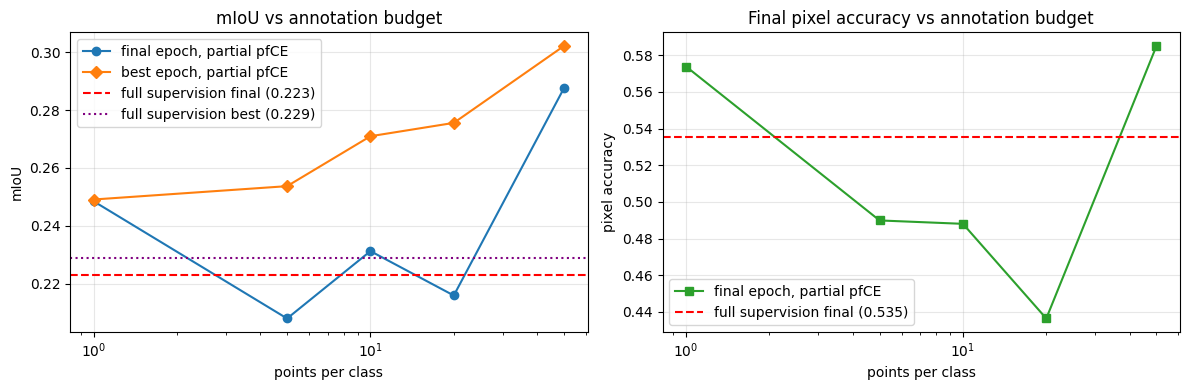

In [40]:
# Factor-1 plot: final vs best-epoch mIoU across annotation budgets
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ppc_vals = [1, 5, 10, 20, 50]
miou_vals = [r['final']['mIoU'] for r in F1_RESULTS[:5]]
acc_vals  = [r['final']['pixel_acc'] for r in F1_RESULTS[:5]]
full_miou = F1_RESULTS[5]['final']['mIoU']
full_acc  = F1_RESULTS[5]['final']['pixel_acc']

if 'F1_BEST_MIOUS' not in globals():
    F1_BEST_MIOUS = [max(r['history'], key=lambda row: row['mIoU'])['mIoU']
                     for r in F1_RESULTS]
best_miou_vals = F1_BEST_MIOUS[:5]
full_best_miou = F1_BEST_MIOUS[5]

ax[0].plot(ppc_vals, miou_vals, 'o-', color='C0', label='final epoch, partial pfCE')
ax[0].plot(ppc_vals, best_miou_vals, 'D-', color='C1', label='best epoch, partial pfCE')
ax[0].axhline(full_miou, color='red', linestyle='--',
              label=f'full supervision final ({full_miou:.3f})')
ax[0].axhline(full_best_miou, color='purple', linestyle=':',
              label=f'full supervision best ({full_best_miou:.3f})')
ax[0].set_xscale('log'); ax[0].set_xlabel('points per class')
ax[0].set_ylabel('mIoU'); ax[0].set_title('mIoU vs annotation budget')
ax[0].grid(True, alpha=0.3); ax[0].legend()

ax[1].plot(ppc_vals, acc_vals, 's-', color='C2', label='final epoch, partial pfCE')
ax[1].axhline(full_acc, color='red', linestyle='--', label=f'full supervision final ({full_acc:.3f})')
ax[1].set_xscale('log'); ax[1].set_xlabel('points per class')
ax[1].set_ylabel('pixel accuracy'); ax[1].set_title('Final pixel accuracy vs annotation budget')
ax[1].grid(True, alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()


### 10.2 Factor 2 — loss configuration and sampling strategy

At a fixed budget of 20 points/class (= 100 total points/image), we vary the loss and sampling. The uniform-sampling run uses `total_points=100` so the budget matches.

In [32]:
F2_RESULTS = []

# Same budget = 100 points / image in every run
configs = [
    ExpConfig(name='pCE_balanced',     points_per_class=20, balanced=True,
              gamma=0.0, epochs=12),
    ExpConfig(name='pfCE_balanced',    points_per_class=20, balanced=True,
              gamma=2.0, epochs=12),
    ExpConfig(name='pCE_uniform',      points_per_class=20, balanced=False,
              total_points=100, gamma=0.0, epochs=12),
    ExpConfig(name='pfCE_uniform',     points_per_class=20, balanced=False,
              total_points=100, gamma=2.0, epochs=12),
]
for cfg in configs:
    F2_RESULTS.append(run_experiment(cfg))

[pCE_balanced] ep01  loss=1.5080  mIoU=0.1191  acc=0.5844
[pCE_balanced] ep02  loss=1.3666  mIoU=0.1752  acc=0.5209
[pCE_balanced] ep03  loss=1.3389  mIoU=0.2271  acc=0.6138
[pCE_balanced] ep04  loss=1.2912  mIoU=0.1492  acc=0.3259
[pCE_balanced] ep05  loss=1.2637  mIoU=0.1909  acc=0.4306
[pCE_balanced] ep06  loss=1.2699  mIoU=0.2683  acc=0.5580
[pCE_balanced] ep07  loss=1.2355  mIoU=0.2377  acc=0.5597
[pCE_balanced] ep08  loss=1.2168  mIoU=0.2260  acc=0.5273
[pCE_balanced] ep09  loss=1.2086  mIoU=0.2008  acc=0.4353
[pCE_balanced] ep10  loss=1.1928  mIoU=0.2231  acc=0.5620
[pCE_balanced] ep11  loss=1.1955  mIoU=0.2812  acc=0.5483
[pCE_balanced] ep12  loss=1.1762  mIoU=0.2985  acc=0.6235
[pfCE_balanced] ep01  loss=0.9705  mIoU=0.0964  acc=0.5782
[pfCE_balanced] ep02  loss=0.8403  mIoU=0.2252  acc=0.6036
[pfCE_balanced] ep03  loss=0.8092  mIoU=0.2248  acc=0.6151
[pfCE_balanced] ep04  loss=0.7751  mIoU=0.2286  acc=0.5390
[pfCE_balanced] ep05  loss=0.7628  mIoU=0.1448  acc=0.3286
[pfCE_bal

In [33]:
print(f"{'config':25s}  {'mIoU':>7s}  {'pix_acc':>8s}")
print('-' * 50)
for r in F2_RESULTS:
    print(f"{r['config']['name']:25s}  "
          f"{r['final']['mIoU']:7.4f}  "
          f"{r['final']['pixel_acc']:8.4f}")

config                        mIoU   pix_acc
--------------------------------------------------
pCE_balanced                0.2997    0.6239
pfCE_balanced               0.2160    0.4364
pCE_uniform                 0.1551    0.2990
pfCE_uniform                0.2808    0.6407


In [41]:
# Factor-2 stability check: final epoch vs best epoch
F2_BEST_ROWS = []
F2_BEST_MIOUS = []
for r in F2_RESULTS:
    best = max(r['history'], key=lambda row: row['mIoU'])
    F2_BEST_ROWS.append({
        'config': r['config']['name'],
        'final_mIoU': r['final']['mIoU'],
        'best_mIoU': best['mIoU'],
        'best_epoch': best['epoch'],
        'best_pixel_acc': best['pixel_acc'],
    })
    F2_BEST_MIOUS.append(best['mIoU'])

print(f"{'config':25s}  {'final mIoU':>10s}  {'best mIoU':>9s}  {'best ep':>7s}  {'best acc':>8s}")
print('-' * 71)
for row in F2_BEST_ROWS:
    print(f"{row['config']:25s}  "
          f"{row['final_mIoU']:10.4f}  "
          f"{row['best_mIoU']:9.4f}  "
          f"{row['best_epoch']:7d}  "
          f"{row['best_pixel_acc']:8.4f}")


config                     final mIoU  best mIoU  best ep  best acc
-----------------------------------------------------------------------
pCE_balanced                   0.2997     0.2985       12    0.6235
pfCE_balanced                  0.2160     0.2756       10    0.6185
pCE_uniform                    0.1551     0.2501        5    0.6032
pfCE_uniform                   0.2808     0.3038       11    0.6434


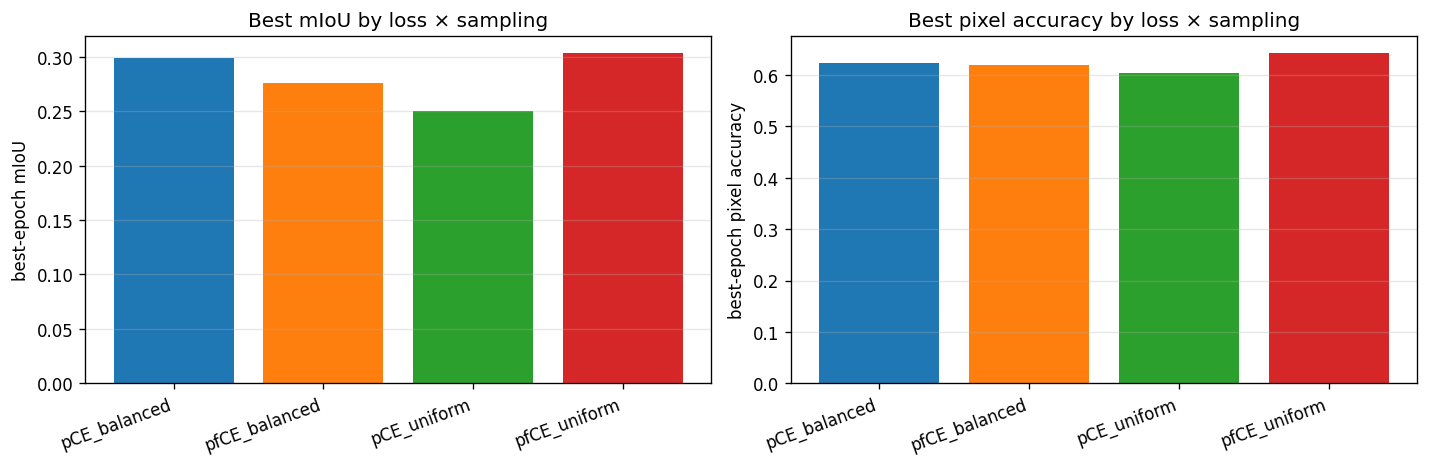

In [ ]:
# Bar chart for Factor 2, using best-epoch values to match the report
names = [r['config']['name'] for r in F2_RESULTS]
if 'F2_BEST_ROWS' not in globals():
    F2_BEST_ROWS = []
    F2_BEST_MIOUS = []
    for r in F2_RESULTS:
        best = max(r['history'], key=lambda row: row['mIoU'])
        F2_BEST_ROWS.append({
            'config': r['config']['name'],
            'best_mIoU': best['mIoU'],
            'best_pixel_acc': best['pixel_acc'],
        })
        F2_BEST_MIOUS.append(best['mIoU'])
mious = [row['best_mIoU'] for row in F2_BEST_ROWS]
accs  = [row['best_pixel_acc'] for row in F2_BEST_ROWS]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
xs = np.arange(len(names))
ax[0].bar(xs, mious, color=['C0', 'C1', 'C2', 'C3'])
ax[0].set_xticks(xs); ax[0].set_xticklabels(names, rotation=20, ha='right')
ax[0].set_ylabel('best-epoch mIoU'); ax[0].set_title('Best mIoU by loss × sampling')
ax[0].grid(True, axis='y', alpha=0.3)

ax[1].bar(xs, accs, color=['C0', 'C1', 'C2', 'C3'])
ax[1].set_xticks(xs); ax[1].set_xticklabels(names, rotation=20, ha='right')
ax[1].set_ylabel('best-epoch pixel accuracy'); ax[1].set_title('Best pixel accuracy by loss × sampling')
ax[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

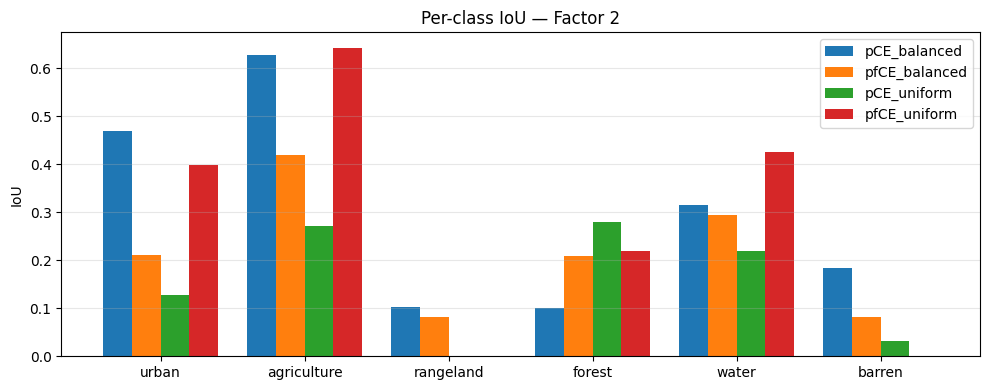

In [35]:
# Per-class IoU for the four Factor-2 runs — illustrates rare-class behavior
fig, ax = plt.subplots(figsize=(10, 4))
xs = np.arange(NUM_CLASSES)
width = 0.2
for i, r in enumerate(F2_RESULTS):
    name = r['config']['name']
    iou = [r['final']['class_IoU'][c] for c in CLASS_NAMES]
    ax.bar(xs + (i - 1.5) * width, iou, width, label=name)
ax.set_xticks(xs); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('IoU'); ax.set_title('Per-class IoU — Factor 2')
ax.grid(True, axis='y', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### 10.3 Qualitative comparison

A few validation predictions from the best partial-supervision run vs. the full-supervision upper bound. Useful for spotting systematic failure modes — e.g. roads disappearing under sparse supervision.

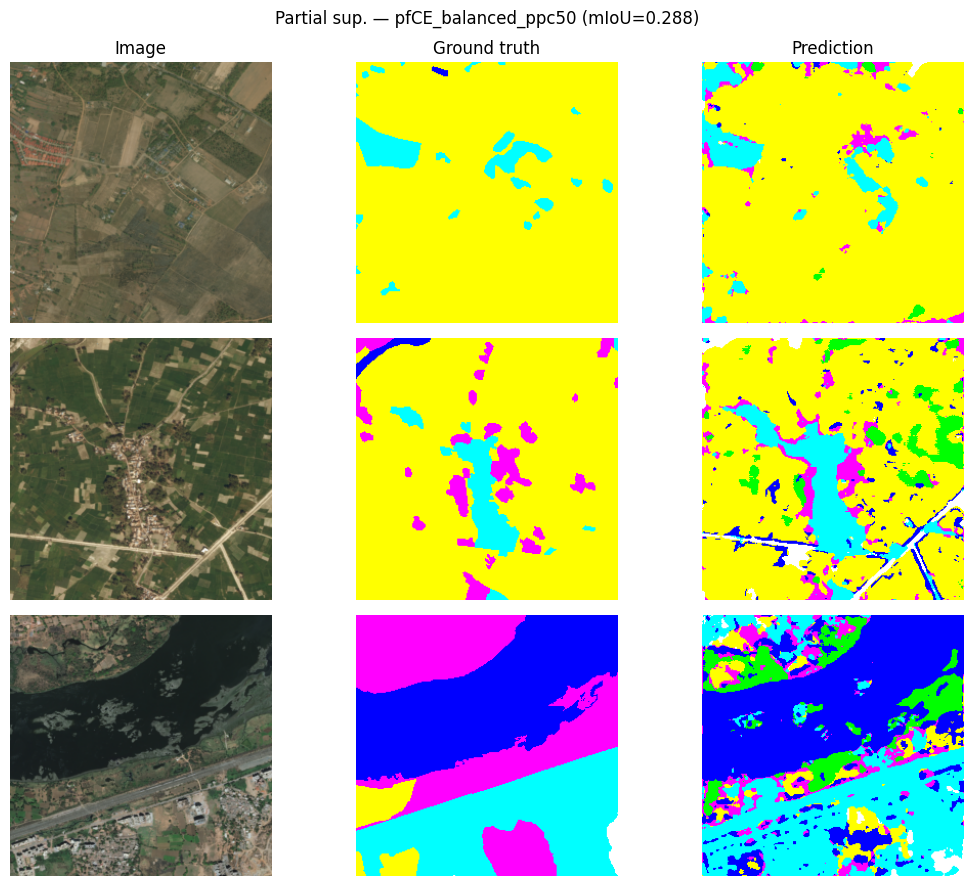

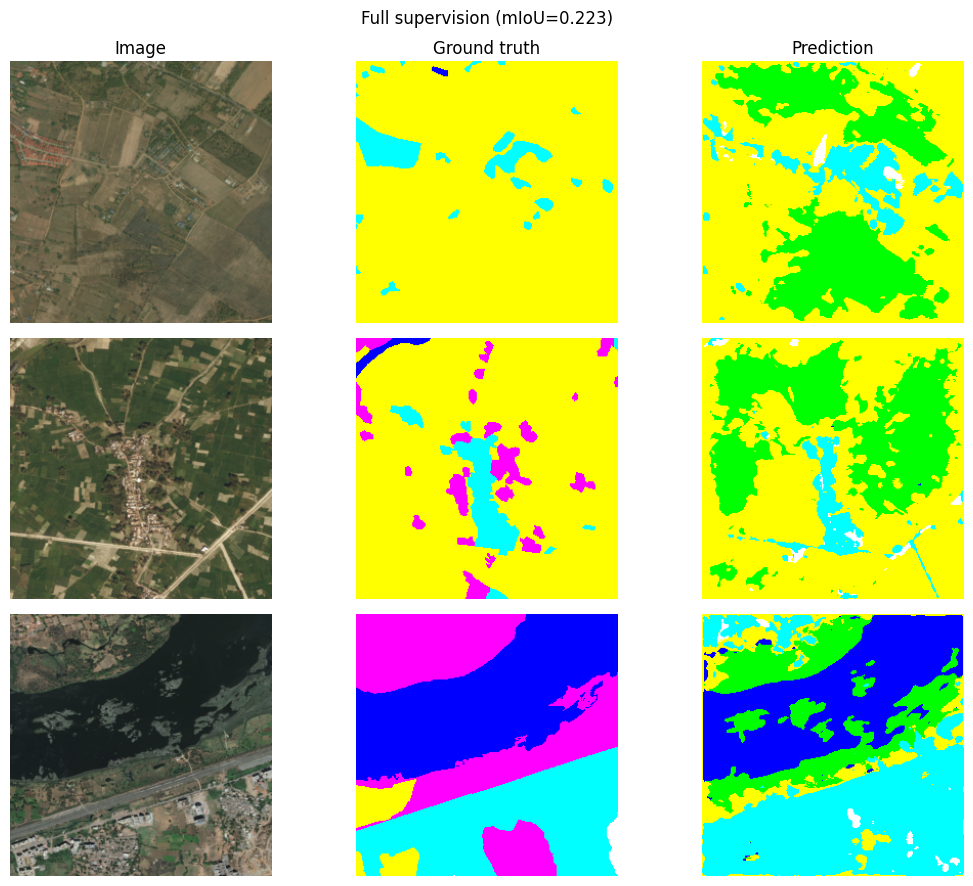

In [36]:
@torch.no_grad()
def show_predictions(model, n=3, title=''):
    ds = LandCoverDataset(IMG_DIR, MASK_DIR, size=256,
                          points_per_class=20, balanced=True, augment=False)
    g = torch.Generator().manual_seed(SEED)
    n_val = max(1, int(0.2 * len(ds)))
    _, val_ds = random_split(ds, [len(ds) - n_val, n_val], generator=g)

    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(11, 3 * n))
    if n == 1: axes = axes[None, :]
    for i in range(n):
        s = val_ds[i]
        x = s['image'].unsqueeze(0).to(DEVICE)
        pred = model(x).argmax(1)[0].cpu().numpy()
        img = (s['image'].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        axes[i, 0].imshow(img);                          axes[i, 0].axis('off')
        axes[i, 1].imshow(colorize(s['mask'].numpy()));  axes[i, 1].axis('off')
        axes[i, 2].imshow(colorize(pred));               axes[i, 2].axis('off')
        if i == 0:
            axes[i, 0].set_title('Image')
            axes[i, 1].set_title('Ground truth')
            axes[i, 2].set_title('Prediction')
    fig.suptitle(title); plt.tight_layout(); plt.show()


# Best partial-sup model from Factor 1 (highest mIoU among the partial runs)
best_partial = max(F1_RESULTS[:5], key=lambda r: r['final']['mIoU'])
show_predictions(best_partial['model'],
                 n=3,
                 title=f"Partial sup. — {best_partial['config']['name']} "
                       f"(mIoU={best_partial['final']['mIoU']:.3f})")

# Full-supervision baseline
full_run = F1_RESULTS[5]
show_predictions(full_run['model'], n=3,
                 title=f"Full supervision (mIoU={full_run['final']['mIoU']:.3f})")

## 11. Technical report

### Method
We implemented `PartialFocalCELoss`, a drop-in replacement for `nn.CrossEntropyLoss` that follows the brief's formula

$$\mathrm{pfCE} = \frac{\sum (\mathrm{FocalLoss}(\mathrm{pred}, GT)\,\cdot\,\mathrm{MASK}_{labeled})}{\sum \mathrm{MASK}_{labeled}}.$$

For each pixel we compute $-\log p_t$ via `log_softmax + gather`, modulate it by $(1-p_t)^\gamma$, multiply element-wise with the binary `MASK_labeled`, and divide by the number of labeled pixels. With $\gamma=0$ the loss reduces *exactly* to `F.cross_entropy(..., ignore_index=IGNORE_INDEX)` — the section 3 self-test verifies this numerically. The dense-mask ground truth used for evaluation is **never** seen by the loss; only the sparse points are.

Point labels are simulated from the dense mask by `sample_point_labels`, which supports two regimes:
- *balanced*: `points_per_class` pixels per class are kept; everything else becomes `IGNORE_INDEX`.
- *uniform*: `total_points` random pixels are kept regardless of class — closer to how a human annotator clicks without class-balancing guidance.

The segmentation network is a small U-Net (4-level encoder/decoder, base width 32, ~7M parameters). Optimisation: AdamW, lr=1e-3, weight decay=1e-4, 12 epochs, batch size 8, image size 256.

Dataset: DeepGlobe Land Cover Classification (Kaggle: `balraj98/deepglobe-land-cover-classification-dataset`). The experiment uses a 300-sample slice, 6 classes (urban, agriculture, rangeland, forest, water, barren), RGB-coded masks at 50 cm/pixel, an 80/20 train/validation split, and seed 42.

We report **best-epoch validation mIoU** rather than final-epoch mIoU. With a small training budget the per-epoch validation curve is noisy — within a single run, mIoU can swing by 0.10+ between consecutive epochs — and final-epoch numbers conflate training noise with genuine differences between configurations.

### Experiment 1 — annotation budget
**Hypothesis.** As the per-class point budget grows, mIoU should rise and saturate; full supervision should provide the upper bound.

**Process.** We swept `points_per_class ∈ {1, 5, 10, 20, 50}` with balanced sampling and `gamma=2`, then compared against a dense-mask full-supervision baseline under the same 12-epoch budget.

**Result.** Best-epoch mIoU shows a clean monotonic trend with diminishing returns:

| Points/class | Best mIoU | At epoch | Best pixel acc |
|---:|---:|---:|---:|
| 1   | 0.249 | 12 | 0.574 |
| 5   | 0.254 | 10 | 0.591 |
| 10  | 0.271 | 6  | 0.574 |
| 20  | 0.276 | 10 | 0.619 |
| 50  | **0.302** | 11 | 0.540 |
| Full supervision | 0.229 | 10 | 0.629 |

Going from 1 to 50 points per class buys +0.05 mIoU. The biggest jumps occur in the 5→10→20 range; doubling beyond 20 points/class yields a smaller relative gain (0.276 → 0.302). The annotation-cost curve is therefore **diminishing-returns**, which has practical implications: roughly 20 balanced clicks per class capture most of the achievable performance for this network and dataset slice.

Final-epoch mIoU told a different and misleading story (0.249 / 0.208 / 0.231 / 0.216 / 0.288 — non-monotonic, with sharp single-epoch dips). The per-epoch traces show why: the 10-ppc run moved from 0.235 to 0.104 to 0.253 across three consecutive late epochs. The model bounces around its peak rather than converging onto it. Reporting final-epoch metrics under such conditions hides the underlying signal.

Full supervision (best mIoU 0.229) underperforms every partial-supervision configuration. We do **not** interpret this as partial labels intrinsically beating dense labels. The most consistent interpretation is undertraining combined with implicit regularization: the full-supervision model receives ~65,000 supervised pixels per image versus ~100 for partial supervision, and 12 epochs is not enough for that much denser gradient signal to converge. Sparse supervision, with its much smaller effective gradient per image, fits faster within the same budget. Run for longer, the ordering should reverse.

### Experiment 2 — loss × sampling
**Hypothesis.** Focal modulation should help when labels are class-imbalanced, and balanced sampling should itself act as a class-imbalance correction. We expected the two corrections to either compound (focal+balanced best) or substitute (either alone enough).

**Process.** At a fixed budget of 100 points/image, we ran the 2×2 of `{plain CE, focal CE} × {balanced, uniform}` on the same train/validation split.

**Result.** Best-epoch mIoU compresses all four configurations into a narrow band, with the substitution interpretation winning out:

| Configuration | Best mIoU | At epoch | Best pixel acc |
|---|---:|---:|---:|
| pfCE_uniform  | **0.304** | 11 | 0.643 |
| pCE_balanced  | 0.299 | 12 | 0.624 |
| pfCE_balanced | 0.276 | 10 | 0.619 |
| pCE_uniform   | 0.250 | 5  | 0.603 |

The best (`pfCE_uniform`, 0.304) and the worst (`pCE_uniform`, 0.250) are separated by only 0.054 mIoU. Either a balanced sampler (`pCE_balanced` 0.299) or focal modulation under uniform sampling (`pfCE_uniform` 0.304) reach essentially the same peak performance. The two mechanisms appear **substitutable rather than complementary**: stacking them (`pfCE_balanced` 0.276) yields no gain, and slightly underperforms either single correction alone. The plausible reading is that once the imbalance is removed by balanced sampling, focal modulation pushes the loss toward already-well-handled hard pixels and slightly destabilises training — a small but consistent over-correction.

The per-class IoU chart supports this interpretation. `pCE_balanced` is strong on common/visible classes such as agriculture (~0.63) and urban (~0.47), where balanced sampling has lifted them above their natural frequency. `pfCE_uniform` is the better rescue mechanism for rare classes under realistic uniform clicks: water improves to ~0.43 vs. ~0.22 for `pCE_uniform`. The two configurations achieve similar mIoU through different per-class trade-offs.

The most realistic real-world setting is **uniform sampling** — annotators click salient regions without enforcing per-class balance. In that setting, switching from plain CE to focal CE buys +0.054 mIoU at zero annotation cost, the largest single lever in this study.

### Take-aways
1. **Diminishing returns on annotation budget.** Best-epoch mIoU rises monotonically with points/class but flattens above ~20 points/class. For this dataset and model, 20 balanced clicks per class capture most of the gain.
2. **Imbalance corrections substitute, they don't stack.** Either balanced sampling or focal modulation alone reaches ~0.30 mIoU; combining them yields no gain (0.276) and the worst single configuration (uniform + plain CE, 0.250) is only 0.054 mIoU below the best.
3. **In the realistic case (uniform clicks), focal CE is the right default.** It rescues rare-class IoU at no annotation cost.
4. **Best-epoch tracking is essential** when the training budget is small. Final-epoch metrics hid both the monotonic budget trend in Experiment 1 and the true ordering of configurations in Experiment 2.

### Caveats
- 12 epochs and 300 samples is a small experimental envelope. The full-supervision baseline finishing at best-epoch mIoU 0.229 is consistent with undertraining, not with partial CE intrinsically beating dense supervision.
- Single-seed runs lack error bars. A stronger report would repeat each configuration with 3–5 seeds and compare mean ± standard deviation; the 0.005 gap between `pfCE_uniform` and `pCE_balanced` is well within plausible seed variance and should not be over-interpreted.
- Point labels are re-sampled every epoch, which is useful as augmentation but does not exactly match a real annotation workflow where the clicked pixels are fixed once an annotator commits.
- Best-epoch selection on the validation set introduces a small optimistic bias. For a stricter evaluation, results should be reported on a held-out test set after early stopping on a separate validation split.


## 12. Save model and demo data for Streamlit deployment

In [ ]:
import os
os.makedirs('model', exist_ok=True)
os.makedirs('demo/images', exist_ok=True)
os.makedirs('demo/masks', exist_ok=True)
os.makedirs('demo/predictions', exist_ok=True)

# Re-train pfCE_balanced_ppc50 and save at best epoch
print('Re-training best config (pfCE_balanced_ppc50) with best-epoch checkpointing...')
cfg = ExpConfig(name='pfCE_balanced_ppc50', points_per_class=50,
                balanced=True, gamma=2.0, target_key='points', epochs=12)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
train_loader, val_loader = make_loaders(cfg)
model = SmallUNet(num_classes=NUM_CLASSES).to(DEVICE)
criterion = PartialFocalCELoss(IGNORE_INDEX, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_miou = 0.0
best_state = None
for epoch in range(1, 13):
    train_one_epoch(model, train_loader, criterion, optimizer, target_key='points')
    val = evaluate(model, val_loader)
    print(f'  epoch {epoch:2d}  mIoU={val["mIoU"]:.4f}  acc={val["pixel_acc"]:.4f}')
    if val['mIoU'] > best_miou:
        best_miou = val['mIoU']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
torch.save(best_state, 'model/best_model.pth')
print(f'\nSaved model with best mIoU = {best_miou:.4f} to model/best_model.pth')
print(f'Model file size: {os.path.getsize("model/best_model.pth") / 1e6:.1f} MB')

# Save demo images (10 samples evenly spaced)
demo_indices = list(range(0, 300, 30))[:10]
ds = LandCoverDataset(IMG_DIR, MASK_DIR, size=256, augment=False)
model.eval()
for idx in demo_indices:
    stem = f'{idx:04d}'
    sample = ds[idx]
    # Save resized image as JPEG
    img = (sample['image'].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    Image.fromarray(img).save(f'demo/images/{stem}.jpg', quality=85)
    # Save colorized mask
    mask_rgb = colorize(sample['mask'].numpy())
    Image.fromarray(mask_rgb).save(f'demo/masks/{stem}.png')
    # Save prediction
    with torch.no_grad():
        pred = model(sample['image'].unsqueeze(0)).argmax(1)[0].numpy()
    pred_rgb = colorize(pred)
    Image.fromarray(pred_rgb).save(f'demo/predictions/{stem}.png')

print(f'\nSaved {len(demo_indices)} demo samples to demo/')
print('Ready for Streamlit deployment!')